In [36]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from jcopml.pipeline import num_pipe, cat_pipe
from jcopml.utils import save_model, load_model
from jcopml.plot import plot_missing_value
from jcopml.feature_importance import mean_score_decrease

from luwiji.logistic_regression import illustration


# Import Data

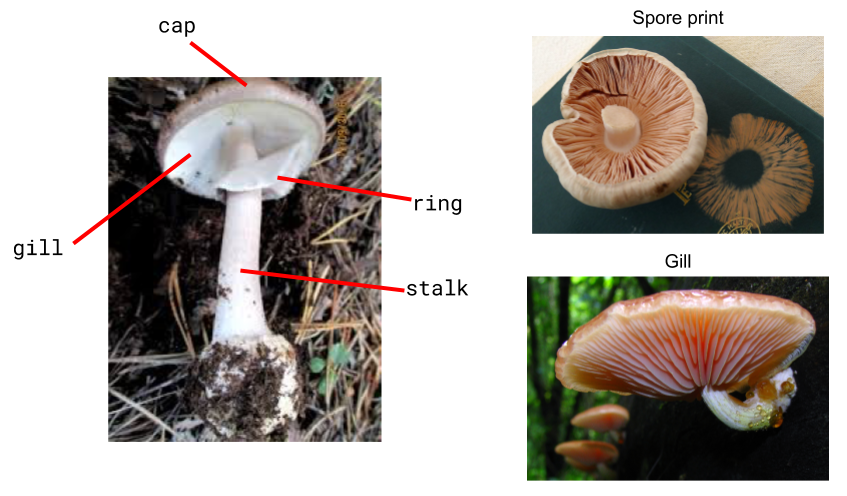

In [13]:
illustration.mushroom

# Membaca Dateset

In [14]:
df = pd.read_csv("data/mushrooms.csv")
df.head()

,edible,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,stalk_surface_below_ring,stalk_color_above_ring,stalk_color_below_ring,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat
0,False,convex,smooth,brown,True,pungent,free,close,narrow,black,...,smooth,white,white,partial,white,1,pendant,black,scattered,urban
1,True,convex,smooth,yellow,True,almond,free,close,broad,black,...,smooth,white,white,partial,white,1,pendant,brown,numerous,grasses
2,True,bell,smooth,white,True,anise,free,close,broad,brown,...,smooth,white,white,partial,white,1,pendant,brown,numerous,meadows
3,False,convex,scaly,white,True,pungent,free,close,narrow,brown,...,smooth,white,white,partial,white,1,pendant,black,scattered,urban
4,True,convex,smooth,gray,False,none,free,crowded,broad,black,...,smooth,white,white,partial,white,1,evanescent,brown,abundant,grasses


# EDA

## a. Kita akan cek data yang bolong kita lihat dalam bentuk persen

,missing_value,%
edible,0,0.00
cap_shape,0,0.00
cap_surface,0,0.00
cap_color,0,0.00
bruises,0,0.00
odor,0,0.00
gill_attachment,0,0.00
gill_spacing,0,0.00
gill_size,0,0.00
gill_color,0,0.00


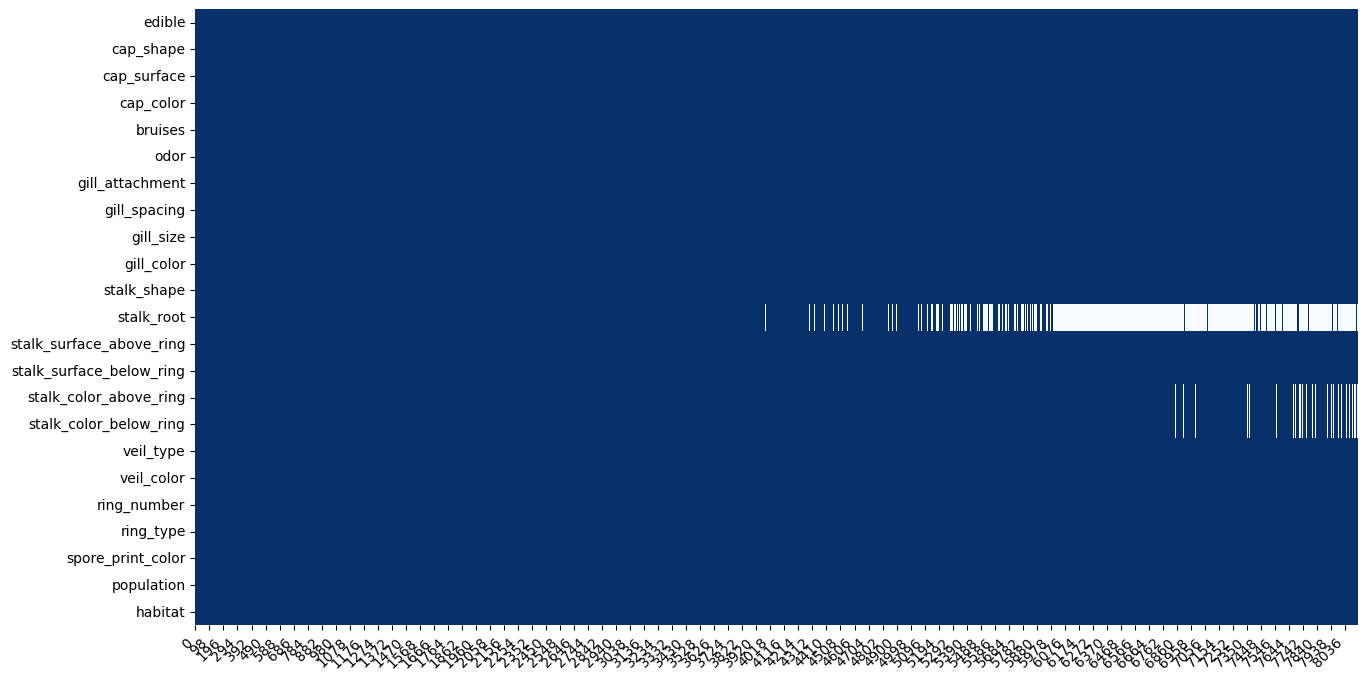

In [15]:
plot_missing_value(df, return_df=True)

## b. Karena ini Klasifikasi harus di cek balance atau tidak kolom target kita 

In [16]:
df.edible.value_counts() 
# edible itu kolom target

edible
True     4208
False    3916
Name: count, dtype: int64

# Association Matrix

##

##association matrix ini di genunakan jika kita tidak tahu secara spesifik dari si dateset kita, misalnya datesetnya tentang biologi saya tidak paham biologi , maka harus di tanya ke orang yang bisa, tapi kita tidak kenal orang yang bisa maka kita pakai association matrix unutk melihat mana sih fitur yang memilki hubungan kuat dengan target, supaya jika fitur nya ada 30 bisa kita hapus beberapa fitur dan kita ambil fitur yang hubungan nya kuat. 

In [17]:
from jcopml.plot import plot_association_matrix

In [18]:
plot_association_matrix(df, "edible", categoric_col='auto')

ValueError: Categorical column should have at least 2 category
You should remove these column from your data -> veil_type

## kenapa error karena satu kolom isi nya kategorinya sama semua / numeric nya sama semua itu bukan fitur gak ada informasi karena value nya sama semua makannya kita buang

In [19]:
df.veil_type.value_counts()

veil_type
partial    8124
Name: count, dtype: int64

In [20]:
df.drop(columns="veil_type", inplace=True)

In [21]:
plot_association_matrix(df,"edible", categoric_col='auto')# lebih baik di isi manual

interactive(children=(ToggleButtons(description='method', options=("Cramer's V", 'Proficiency U(X|Y)', 'Profic…

# dari asociation matrix di atas fitur  yang berkolerasi kuat terhadap target jika teshold nya 60 itu  ada odor , gill_color , ring_type,spore_print_color.

In [22]:
# kita pakai 4 column yang fitur nya kuat 
X = df[["odor","gill_color","ring_type","spore_print_color"]]
y = df.edible

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((6499, 4), (1625, 4), (6499,), (1625,))

# Training

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.multiclass import OneVsRestClassifier
from jcopml.tuning import grid_search_params as gsp # lebih efisien

In [24]:
X_train

,odor,gill_color,ring_type,spore_print_color
7873,spicy,buff,evanescent,white
6515,foul,buff,evanescent,white
6141,fishy,buff,evanescent,white
2764,none,purple,pendant,brown
438,anise,black,pendant,brown
...,...,...,...,...
5226,foul,buff,evanescent,white
5390,none,white,evanescent,white
860,anise,white,pendant,brown
7603,foul,buff,evanescent,white


In [25]:
preprocessor = ColumnTransformer([
    ("categoric",cat_pipe(encoder='onehot'),X_train.columns),
    
])

pipeline = Pipeline([
    ("prep", preprocessor),
    ("algo", OneVsRestClassifier(LogisticRegression( solver='lbfgs', n_jobs=-1, random_state=42)))  # Memperbaiki posisi parameter
])

param_grid = {
    "algo__estimator__C": [0.1, 1, 10],  
    "algo__estimator__fit_intercept": [True, False]
}

model = GridSearchCV(pipeline, param_grid, cv=3,  n_jobs =-1, verbose=1) # maksud dari n_jobs = -1 gunakan semu cpu yang ada 
model.fit(X_train,y_train)

print(model.best_params_)
print(model.score(X_train, y_train), model.best_score_, model.score(X_test, y_test))

Fitting 3 folds for each of 6 candidates, totalling 18 fits
{'algo__estimator__C': 10, 'algo__estimator__fit_intercept': True}
0.9949222957378058 0.9944606149803219 0.9932307692307693


# Evaluation

In [26]:
from jcopml.plot import plot_confusion_matrix, plot_association_matrix, plot_classification_report, plot_roc_curve, plot_pr_curve

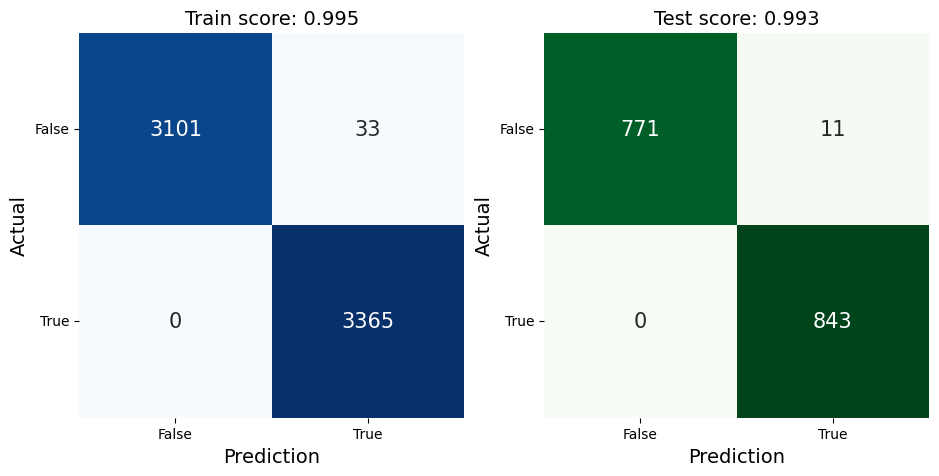

In [57]:
plot_confusion_matrix(X_train, y_train, X_test, y_test, model)

In [27]:
plot_classification_report(X_train, y_train, X_test, y_test, model, report=True)

Train report
              precision    recall  f1-score   support

       False       1.00      0.99      0.99      3134
        True       0.99      1.00      1.00      3365

    accuracy                           0.99      6499
   macro avg       1.00      0.99      0.99      6499
weighted avg       0.99      0.99      0.99      6499


Test report
              precision    recall  f1-score   support

       False       1.00      0.99      0.99       782
        True       0.99      1.00      0.99       843

    accuracy                           0.99      1625
   macro avg       0.99      0.99      0.99      1625
weighted avg       0.99      0.99      0.99      1625



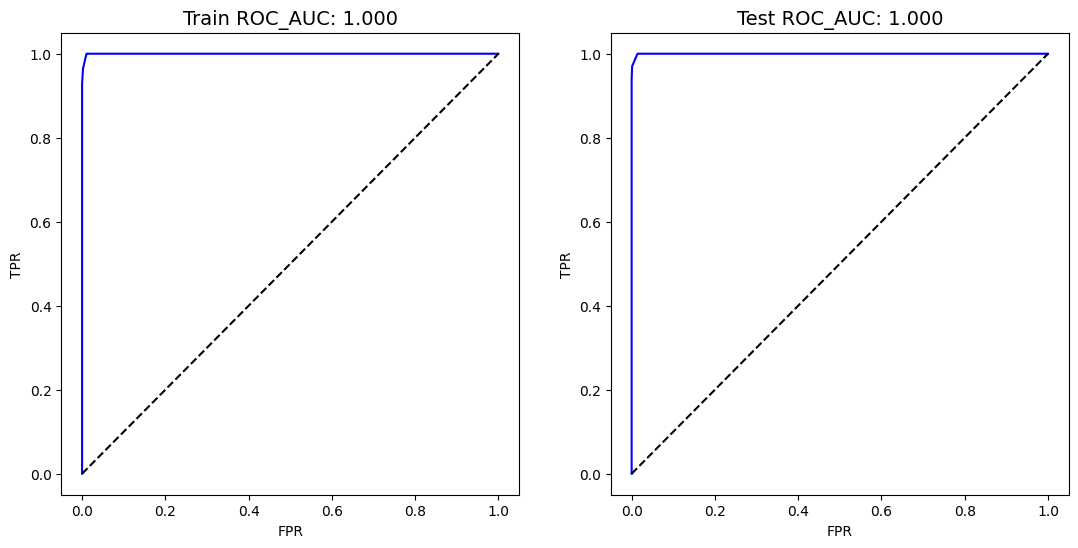

In [28]:
plot_roc_curve(X_train, y_train, X_test, y_test, model)

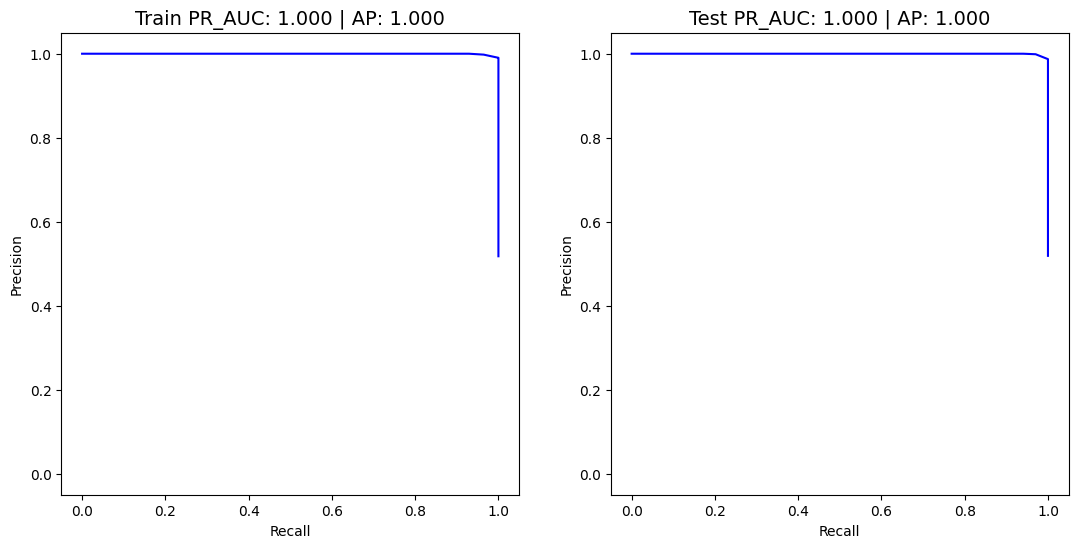

In [29]:
plot_pr_curve(X_train, y_train, X_test, y_test, model)

# Peature Importance

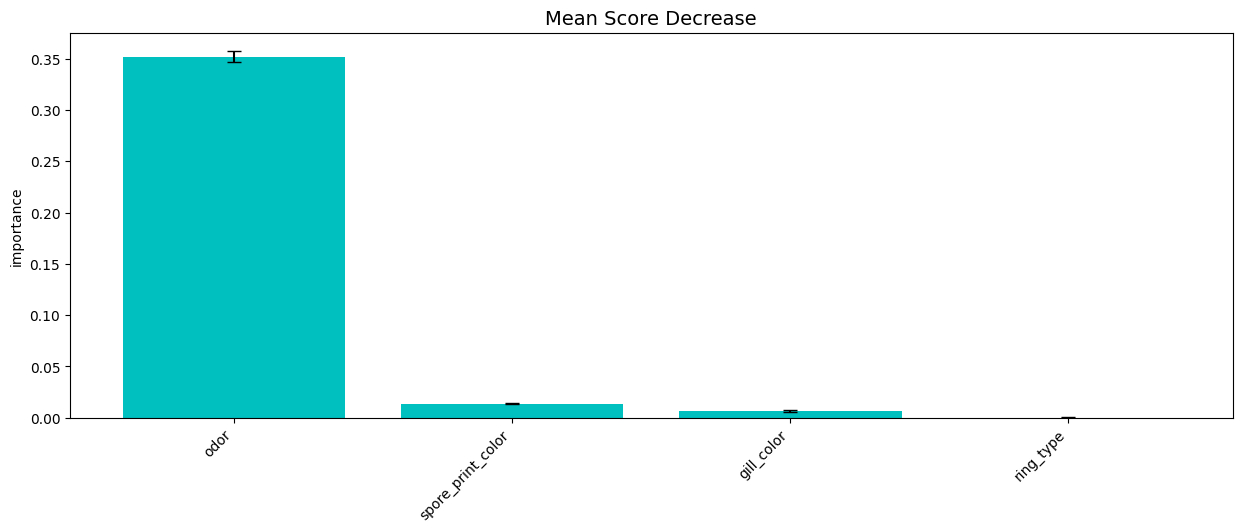

In [30]:
df_imp = mean_score_decrease(X_train, y_train, model, plot=True, topk=10)
# ternyata yang sangat berpengaruh ordor

# insight from data

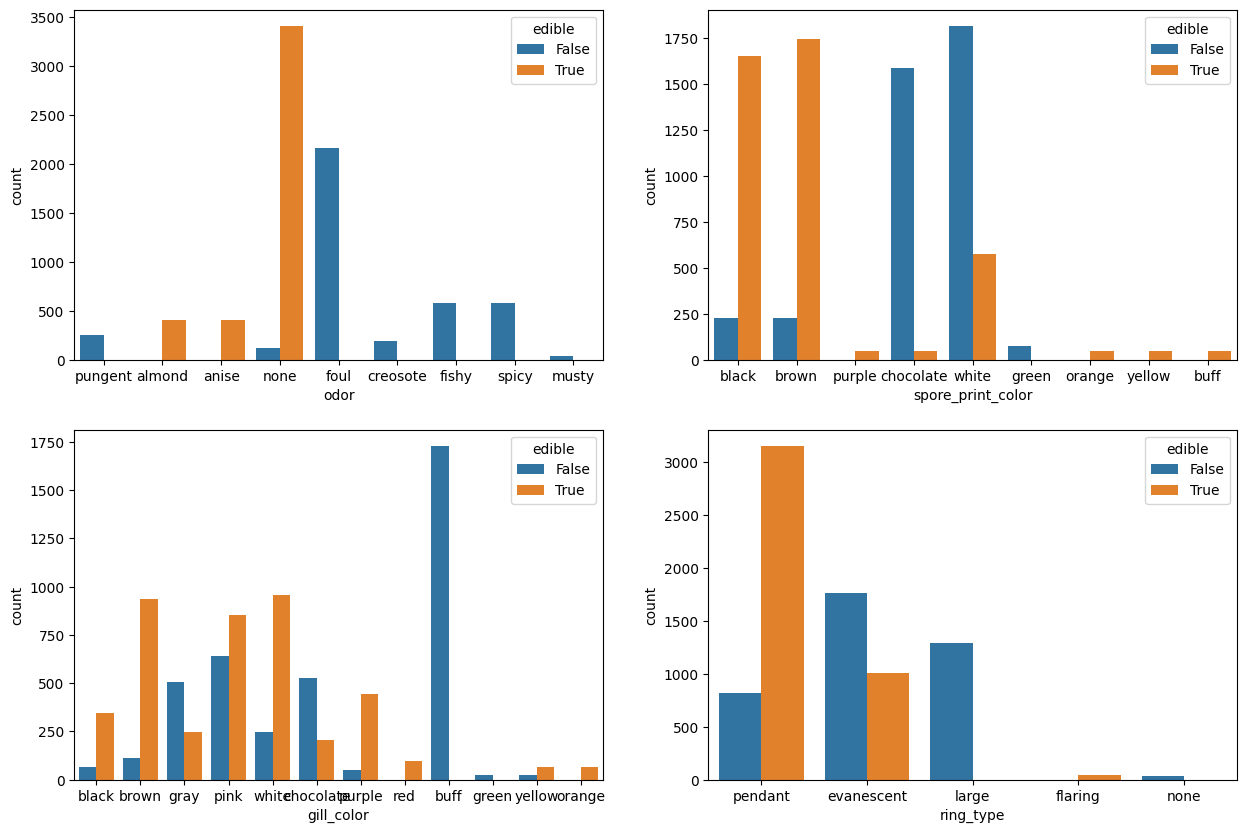

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Menentukan ukuran figure
plt.figure(figsize=(15, 10))

# Plot pertama
plt.subplot(221)
sns.countplot(x='odor', data=df, hue='edible')

# Plot kedua
plt.subplot(222)
sns.countplot(x='spore_print_color', data=df, hue='edible')

# Plot ketiga
plt.subplot(223)
sns.countplot(x='gill_color', data=df, hue='edible')

# Plot keempat
plt.subplot(224)
sns.countplot(x='ring_type', data=df, hue='edible')

# Menampilkan plot
plt.show()


# Correlation Ration (Opsional)

# hubungan data numeric dengan categorik

In [33]:
from jcopml.plot import plot_correlation_ratio

In [34]:
cols_cat = ["edible", "gill_color", "ring_type", "spore_print_color"]
le = LabelEncoder()

# Buat DataFrame baru yang hanya berisi kolom yang dibutuhkan
df_subset = df[cols_cat + ["ring_number"]].copy()
for col in cols_cat:
    df_subset[col] = le.fit_transform(df_subset[col])

print(df_subset.dtypes)  # pastikan semua int/float dulu

plot_correlation_ratio(df_subset, cols_cat, ["ring_number"])

NameError: name 'LabelEncoder' is not defined

# kesimpulannya ring_number itu tidak berpengarus terhadap edible(kolom target kita), jadi gak papa tadi kita buang tadi 